In [1]:
# --------------------------------------------------- 
# LOAD DATA 
# ---------------------------------------------------
import pandas as pd

df = pd.read_csv("cardio_train.csv", sep=";")

print("Dataset shape:", df.shape)
df.head()

Dataset shape: (70000, 13)


,id,age,gender,height,weight,ap_hi,ap_lo,cholesterol,gluc,smoke,alco,active,cardio
0,0,18393,2,168,62.0,110,80,1,1,0,0,1,0
1,1,20228,1,156,85.0,140,90,3,1,0,0,1,1
2,2,18857,1,165,64.0,130,70,3,1,0,0,0,1
3,3,17623,2,169,82.0,150,100,1,1,0,0,1,1
4,4,17474,1,156,56.0,100,60,1,1,0,0,0,0


In [2]:
# --------------------------------------------------- 
# PREPROCESSING 
# ---------------------------------------------------

# Removing ID column
df = df.drop(columns=["id"])

# Converting age from days to years
df["age_years"] = (df["age"] / 365.25).round(1)

# Calculating BMI
df["height_m"] = df["height"] / 100
df["bmi"] = df["weight"] / (df["height_m"] ** 2)
df = df.drop(columns=["age", "height_m"])

Invalid blood pressure rows: 1332
BMI outliers: 1995
Systolic BP outliers: 1435
Diastolic BP outliers: 4632
Invalid BMI rows: 39


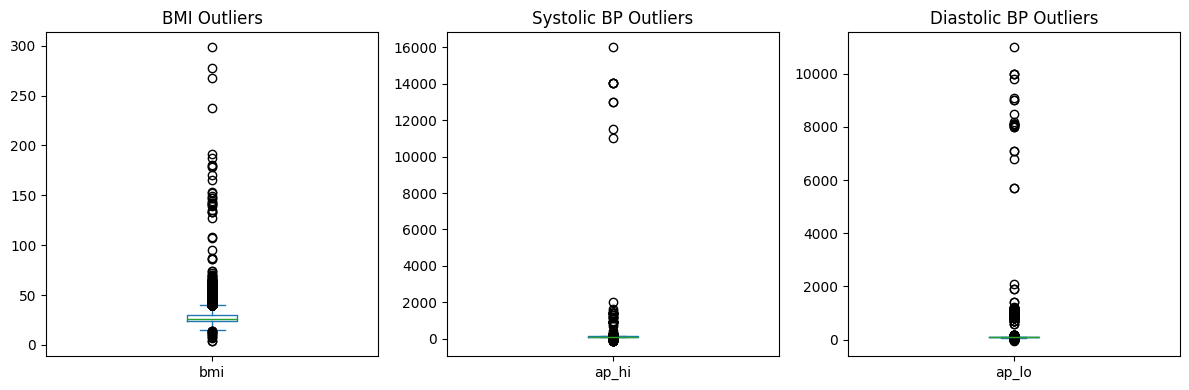

Total noisy rows detected: 1368


,gender,height,weight,ap_hi,ap_lo,cholesterol,gluc,smoke,alco,active,cardio,age_years,bmi
224,2,76,55.0,120,80,1,1,0,0,1,0,59.7,95.221607
228,2,183,98.0,160,1100,1,2,1,0,1,1,47.9,29.263340
241,2,157,60.0,160,1000,2,1,0,0,0,1,60.0,24.341758
260,1,150,83.0,140,800,1,1,0,0,1,1,49.9,36.888889
329,1,176,63.0,160,1000,2,2,0,0,0,1,64.1,20.338326


In [3]:
# --------------------------------------------------- 
# IDENTIFY SIGNIFICANT NOISE & OUTLIERS IN THE DATASET
# --------------------------------------------------- 
invalid_bp = df[
    (df["ap_hi"] < 70) | (df["ap_hi"] > 250) | # impossible systolic
    (df["ap_lo"] < 40) | (df["ap_lo"] > 150) | # impossible diastolic
    (df["ap_hi"] < df["ap_lo"]) # swapped values
    ]

print("Invalid blood pressure rows:", invalid_bp.shape[0])

def detect_iqr_outliers(series):
    Q1 = series.quantile(0.25)
    Q3 = series.quantile(0.75) 
    IQR = Q3 - Q1
    lower = Q1 - 1.5 * IQR
    upper = Q3 + 1.5 * IQR
    return series[(series < lower) | (series > upper)]

bmi_outliers = detect_iqr_outliers(df["bmi"])
ap_hi_outliers = detect_iqr_outliers(df["ap_hi"]) 
ap_lo_outliers = detect_iqr_outliers(df["ap_lo"])

print("BMI outliers:", bmi_outliers.shape[0])
print("Systolic BP outliers:", ap_hi_outliers.shape[0]) 
print("Diastolic BP outliers:", ap_lo_outliers.shape[0])

invalid_bmi = df[(df["bmi"] < 10) | (df["bmi"] > 80)] 
print("Invalid BMI rows:", invalid_bmi.shape[0])

#VISUALIZE OUTLIERS WITH BOXPLOTS
from matplotlib import pyplot as plt

plt.figure(figsize=(12, 4)) 
plt.subplot(1, 3, 1) 
df["bmi"].plot(kind="box") 
plt.title("BMI Outliers") 
plt.subplot(1, 3, 2) 
df["ap_hi"].plot(kind="box") 
plt.title("Systolic BP Outliers") 
plt.subplot(1, 3, 3) 
df["ap_lo"].plot(kind="box") 
plt.title("Diastolic BP Outliers") 
plt.tight_layout() 
plt.show()

#COMBINED NOISE SUMMARY MASK
noise_mask = ( (df["ap_hi"] < 70) | (df["ap_hi"] > 250) | (df["ap_lo"] < 40) | (df["ap_lo"] > 150) | (df["ap_hi"] < df["ap_lo"]) | (df["bmi"] < 10) | (df["bmi"] > 80) ) 
print("Total noisy rows detected:", df[noise_mask].shape[0]) 
df[noise_mask].head()


In [4]:
# --------------------------------------------------- 
# Handle noise and outliers
# ---------------------------------------------------

# Remove extreme BMI outliers 
df = df[(df["bmi"] >= 15) & (df["bmi"] <= 60)]

#Fix invalid blood pressure values
mask_swap = df["ap_hi"] < df["ap_lo"]
df.loc[mask_swap, ["ap_hi", "ap_lo"]] = df.loc[mask_swap, ["ap_lo", "ap_hi"]].values

# Clamp values to medically reasonable ranges
df["ap_hi"] = df["ap_hi"].clip(lower=70, upper=250)
df["ap_lo"] = df["ap_lo"].clip(lower=40, upper=150)

print("After cleaning:", df.shape)
df.head()

After cleaning: (69907, 13)


,gender,height,weight,ap_hi,ap_lo,cholesterol,gluc,smoke,alco,active,cardio,age_years,bmi
0,2,168,62.0,110,80,1,1,0,0,1,0,50.4,21.967120
1,1,156,85.0,140,90,3,1,0,0,1,1,55.4,34.927679
2,1,165,64.0,130,70,3,1,0,0,0,1,51.6,23.507805
3,2,169,82.0,150,100,1,1,0,0,1,1,48.2,28.710479
4,1,156,56.0,100,60,1,1,0,0,0,0,47.8,23.011177


In [5]:
# --------------------------------------------------- 
# Selecting input features
# --------------------------------------------------- 
features = [
    "age_years",
    "gender",
    "bmi",
    "ap_hi",
    "ap_lo",
    "cholesterol",
    "gluc",
    "smoke",
    "alco",
    "active"
]

X = df[features]
y = df["cardio"]

print("X shape:", X.shape)
print("Target distribution:")
print(y.value_counts(normalize=True))

X shape: (69907, 10)
Target distribution:
cardio
0    0.500308
1    0.499692
Name: proportion, dtype: float64


In [6]:
# --------------------------------------------------- 
# TRAIN/TEST SPLIT 
# ---------------------------------------------------
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

print("Training set:", X_train.shape)
print("Testing set :", X_test.shape)

Training set: (55925, 10)
Testing set : (13982, 10)


In [7]:
# --------------------------------------------------- 
# APPLY SMOTE (ONLY ON TRAINING SET) 
# ---------------------------------------------------
from imblearn.over_sampling import SMOTE

sm = SMOTE(random_state=42)
X_train_res, y_train_res = sm.fit_resample(X_train, y_train)
print("Before SMOTE:", y_train.value_counts(normalize=True))
print("After SMOTE:", y_train_res.value_counts(normalize=True))

Before SMOTE: cardio
0    0.500313
1    0.499687
Name: proportion, dtype: float64
After SMOTE: cardio
1    0.5
0    0.5
Name: proportion, dtype: float64


In [8]:
# --------------------------------------------------- 
# TRAIN MODEL
# ---------------------------------------------------
from sklearn.tree import DecisionTreeClassifier

final_model = DecisionTreeClassifier(
    criterion="entropy",
    max_depth=None,
    min_samples_leaf=10,
    min_samples_split=50,
    random_state=42,
    class_weight="balanced"
)

final_model.fit(X_train_res, y_train_res)
print("Final MVP model trained")

Final MVP model trained


In [9]:
# ---------------------------------------------------
# EVALUATION Results
# ---------------------------------------------------
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, classification_report

y_pred_final = final_model.predict(X_test)

print("Accuracy :", round(accuracy_score(y_test, y_pred_final), 4))
print("Precision:", round(precision_score(y_test, y_pred_final), 4))
print("Recall   :", round(recall_score(y_test, y_pred_final), 4))
print("F1-score :", round(f1_score(y_test, y_pred_final), 4))
print("\nReport:\n", classification_report(y_test, y_pred_final))

Accuracy : 0.717
Precision: 0.7275
Recall   : 0.6933
F1-score : 0.71

Report:
               precision    recall  f1-score   support

           0       0.71      0.74      0.72      6995
           1       0.73      0.69      0.71      6987

    accuracy                           0.72     13982
   macro avg       0.72      0.72      0.72     13982
weighted avg       0.72      0.72      0.72     13982



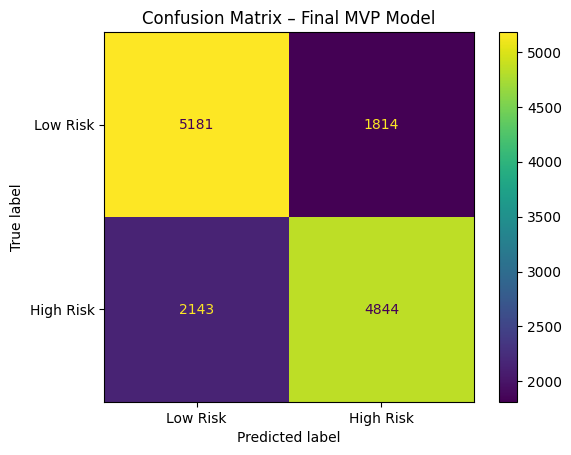

In [10]:
# --------------------------------------------------- 
# Confusion Matrix 
# ---------------------------------------------------
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay
import matplotlib.pyplot as plt

cm = confusion_matrix(y_test, y_pred_final)
ConfusionMatrixDisplay(cm, display_labels=["Low Risk", "High Risk"]).plot()
plt.title("Confusion Matrix – Final MVP Model")
plt.show()

In [11]:
# --------------------------------------------------- 
# PREDICTION FUNCTION
# ---------------------------------------------------

def predict_risk(age_years, gender, bmi, ap_hi, ap_lo, cholesterol, gluc, smoke, alco, active):
    sample = pd.DataFrame([{
        "age_years": age_years,
        "gender": gender,
        "bmi": bmi,
        "ap_hi": ap_hi,
        "ap_lo": ap_lo,
        "cholesterol": cholesterol,
        "gluc": gluc,
        "smoke": smoke,
        "alco": alco,
        "active": active
    }])

    pred = final_model.predict(sample)[0]
    prob = final_model.predict_proba(sample)[0][1]

    label = "High Risk" if pred == 1 else "Low Risk"
    return label, round(float(prob), 3)

# Example situation
example_age_years = 50
example_gender = 2 # 1 = female, 2 = male
example_bmi = 36
example_ap_hi = 130 # systolic BP
example_ap_lo = 90 # diastolic BP
example_cholesterol = 1 # 1 = normal
example_gluc = 1 # 1 = normal
example_smoke = 1 # smokes
example_alco = 1 # drinks alcohol
example_active = 1 # physically active

print(predict_risk(
    example_age_years,
    example_gender,
    example_bmi, 
    example_ap_hi,
    example_ap_lo,
    example_cholesterol,
    example_gluc,
    example_smoke,
    example_alco,
    example_active))

# SAVE MODEL
import joblib

joblib.dump(final_model, "final_model.pkl")


# python -m streamlit run app.py

('High Risk', 0.75)


['final_model.pkl']